In [1]:
# =========================================
# 1. IMPORTS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# =========================================
# 2. LOAD PREPROCESSED DATASET
# =========================================

df = pd.read_csv("data/credit_risk_preprocessed.csv")

print("Shape:", df.shape)
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,18.0,PERSONAL,D,29800,16.02,1,0.5,Y,3
1,21,14400,OWN,5.0,EDUCATION,B,1000,11.14,0,0.1,N,2
2,25,14400,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.5,N,3
3,23,65500,RENT,4.0,MEDICAL,C,29800,15.23,1,0.5,N,2
4,24,54400,RENT,8.0,MEDICAL,C,29800,14.27,1,0.5,Y,4


In [3]:
# =========================================
# 3. FEATURES & TARGET
# =========================================

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 11)
y shape: (32581,)


In [4]:
# =========================================
# 4. TRAIN / VAL / TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temp into validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train: (22806, 11)
Validation: (4887, 11)
Test: (4888, 11)

Train distribution:
 loan_status
0    0.781856
1    0.218144
Name: proportion, dtype: float64

Validation distribution:
 loan_status
0    0.78187
1    0.21813
Name: proportion, dtype: float64

Test distribution:
 loan_status
0    0.78171
1    0.21829
Name: proportion, dtype: float64


In [5]:
# =========================================
# 5. PREPROCESSING PIPELINE
# =========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Numeric pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [7]:
# ====================
# EXPERIMENT 5: TABNET
# ====================

In [8]:
X_train_np = preprocessor.fit_transform(X_train)
X_val_np   = preprocessor.transform(X_val)
X_test_np  = preprocessor.transform(X_test)

y_train_np = y_train.values
y_val_np   = y_val.values
y_test_np  = y_test.values

In [9]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(
    n_d=8,
    n_a=8,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=1e-2),
    seed=42
)

X_tr = X_train_np[:15000]
y_tr = y_train_np[:15000]

X_va = X_val_np[:3000]
y_va = y_val_np[:3000]

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_tr),
    y=y_tr
)

class_weights = dict(zip(np.unique(y_tr), weights))
sample_weights = np.array([class_weights[y] for y in y_tr])

tabnet.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    max_epochs=30,
    patience=7,
    batch_size=2048,
    weights=sample_weights
)

/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.8735  | val_0_auc: 0.5051  |  0:00:00s
epoch 1  | loss: 0.68673 | val_0_auc: 0.57358 |  0:00:00s
epoch 2  | loss: 0.62184 | val_0_auc: 0.61355 |  0:00:00s
epoch 3  | loss: 0.58453 | val_0_auc: 0.65131 |  0:00:01s
epoch 4  | loss: 0.54357 | val_0_auc: 0.69736 |  0:00:01s
epoch 5  | loss: 0.51968 | val_0_auc: 0.75885 |  0:00:01s
epoch 6  | loss: 0.49328 | val_0_auc: 0.80329 |  0:00:02s
epoch 7  | loss: 0.49011 | val_0_auc: 0.81148 |  0:00:02s
epoch 8  | loss: 0.47282 | val_0_auc: 0.81449 |  0:00:02s
epoch 9  | loss: 0.4668  | val_0_auc: 0.83816 |  0:00:02s
epoch 10 | loss: 0.44938 | val_0_auc: 0.84924 |  0:00:03s
epoch 11 | loss: 0.44972 | val_0_auc: 0.85026 |  0:00:03s
epoch 12 | loss: 0.44207 | val_0_auc: 0.85218 |  0:00:03s
epoch 13 | loss: 0.42759 | val_0_auc: 0.85487 |  0:00:04s
epoch 14 | loss: 0.43489 | val_0_auc: 0.86139 |  0:00:04s
epoch 15 | loss: 0.42758 | val_0_auc: 0.86684 |  0:00:04s
epoch 16 | loss: 0.41085 | val_0_auc: 0.87243 |  0:00:05s
epoch 17 | los

/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [10]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

y_pred = tabnet.predict(X_test_np)
y_prob = tabnet.predict_proba(X_test_np)[:, 1]

print("TabNet Results:")
print("ROC-AUC:", roc_auc_score(y_test_np, y_prob))
print("Precision:", precision_score(y_test_np, y_pred))
print("Recall:", recall_score(y_test_np, y_pred))
print("F1:", f1_score(y_test_np, y_pred))

TabNet Results:
ROC-AUC: 0.8972800390090083
Precision: 0.6548100242522231
Recall: 0.7591377694470478
F1: 0.703125


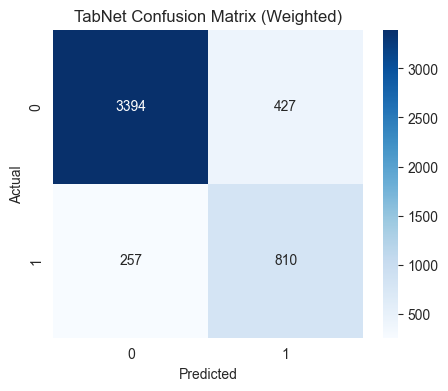

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("TabNet Confusion Matrix (Weighted)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

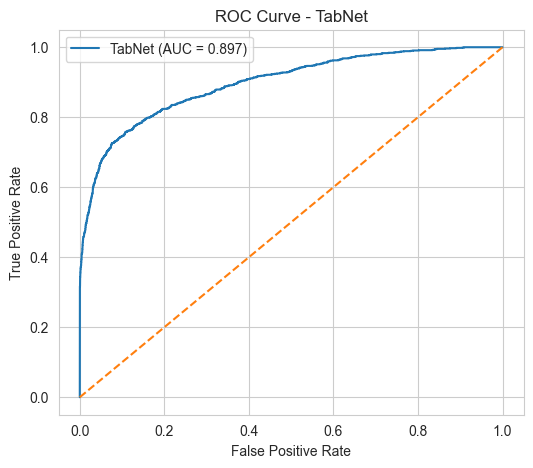

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_np, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="TabNet (AUC = {:.3f})".format(roc_auc_score(y_test_np, y_prob)))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TabNet")
plt.legend()
plt.show()

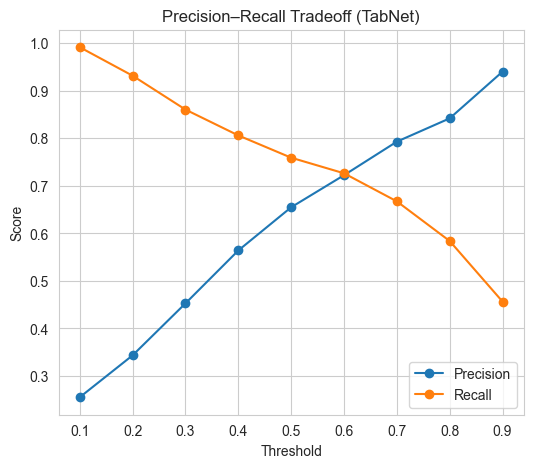

In [13]:
thresholds = np.linspace(0.1, 0.9, 9)

precision_list = []
recall_list = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precision_list.append(precision_score(y_test_np, y_pred_t))
    recall_list.append(recall_score(y_test_np, y_pred_t))

plt.figure(figsize=(6,5))
plt.plot(thresholds, precision_list, marker='o', label="Precision")
plt.plot(thresholds, recall_list, marker='o', label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff (TabNet)")
plt.legend()
plt.show()

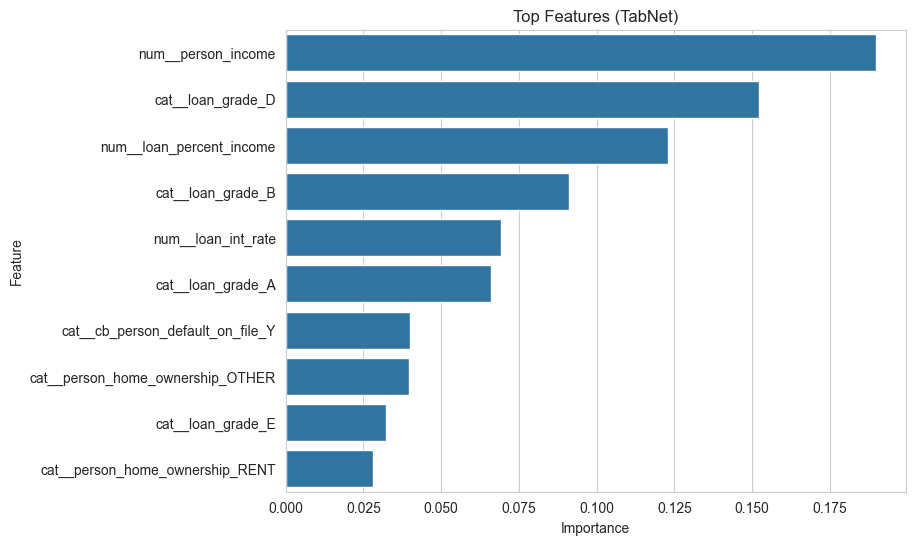

In [14]:
import numpy as np

importances = tabnet.feature_importances_

feature_names = preprocessor.get_feature_names_out()

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_features = imp_df.head(10)

plt.figure(figsize=(8,6))
sns.barplot(data=top_features, y="Feature", x="Importance")
plt.title("Top Features (TabNet)")
plt.show()

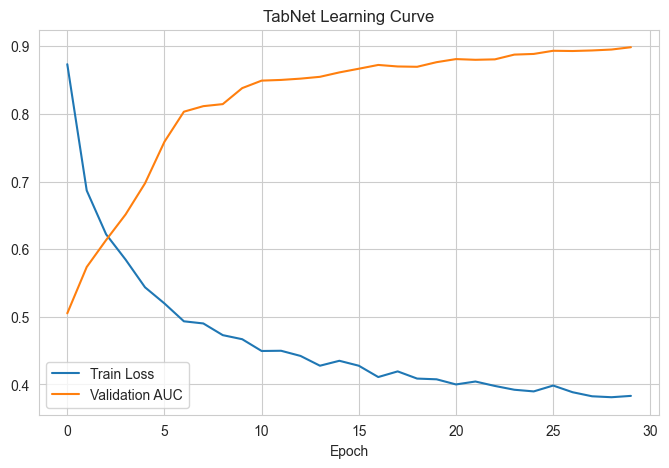

In [15]:
plt.figure(figsize=(8,5))

plt.plot(tabnet.history["loss"], label="Train Loss")
plt.plot(tabnet.history["val_0_auc"], label="Validation AUC")

plt.xlabel("Epoch")
plt.title("TabNet Learning Curve")
plt.legend()
plt.show()

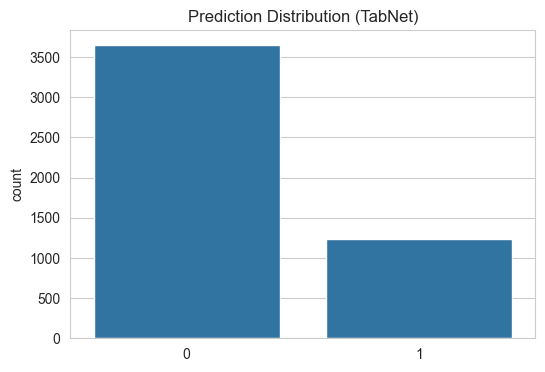

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_pred)
plt.title("Prediction Distribution (TabNet)")
plt.show()